2026-06-05 15:44:24,796 - INFO - Plage commune: [0.05, 20.00]
2026-06-05 15:44:24,800 - INFO - Plage commune: [0.05, 20.00]
2026-06-05 15:44:24,804 - INFO - Plage commune: [0.05, 20.00]


['Pt', 'Au', 'Co']


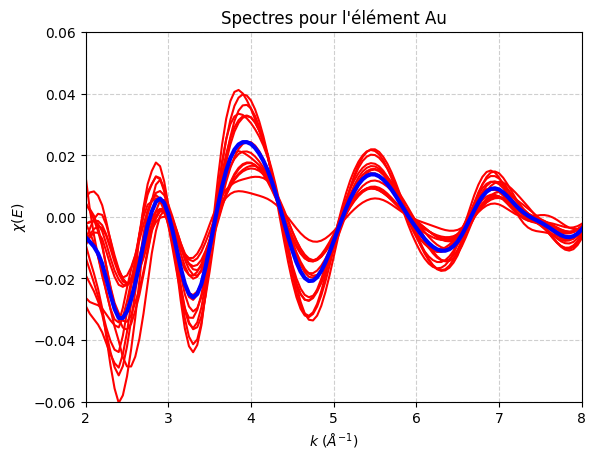

In [56]:
import HBPy.Molecule.Tools
from pathlib import Path
import numpy
from collections import defaultdict
import matplotlib.pyplot as plt


dossier = Path("/home/bulou/src/ATOMOD/simul/feff_input_files/")
# Parcourir tout le contenu
series = defaultdict(list)
list_elt=[]
for element in dossier.iterdir():
    #print(element.name)
    data=Path(f"{dossier}/{element.name}/xmu.dat")
    if data.exists():
        energy, chi = numpy.loadtxt(data, comments='#', usecols=(2, 5), unpack=True)
        clef=element.name.split("_")[0]
        if clef in series:
            series[clef].append((energy,chi))
        else:
            series[clef]=[(energy,chi)]
            list_elt.append(clef)
print(list_elt)

for elt in list_elt:
    k,chi,dev=HBPy.Molecule.Tools.mk_mean(series[elt])
    series[elt].append((k,chi))

for i, (k, chi) in enumerate(series[clef][:-1]):
    # L'utilisation de 'enumerate' donne un compteur 'i' (0, 1, 2...) très pratique pour la légende
    plt.plot(k, chi, label=f"Configuration {i+1}",color='red')
k,mu=series[clef][-1]
plt.plot(k,mu, label=f"Configuration {i+1}",color='blue',linewidth=3)

# Esthétique du graphique
plt.xlabel(r"$k \ (\AA^{-1})$")
plt.ylabel(r"$\chi(E)$") # Le 'r' permet de lire correctement les caractères spéciaux
plt.title(f"Spectres pour l'élément {clef}")
#plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(2, 8)
plt.ylim(-0.06,0.06)
plt.show()

In [42]:
import HBPy

In [43]:
dir(HBPy)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']